Matriz inicial de feromônio:
[[1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]]
Vizinhos do nó 0: [1, 2]
Vizinhos do nó 2: [0, 1, 3, 4]

Rotas encontradas:
Formiga 1: [0, 1, 2, 4, 3, 5]
Formiga 2: [0, 2, 1, 3, 4, 5]
Formiga 3: [0, 1, 2, 3, 4, 5]
Formiga 4: [0, 1, 2, 3, 4, 5]
Formiga 5: None

Rota: [0, 2, 1, 3, 4, 5]
Custo: 13.0

========== RESULTADO ==========
Melhor rota encontrada: [0, 1, 2, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO lab 2 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 4, 5]
Melhor custo: 8.0


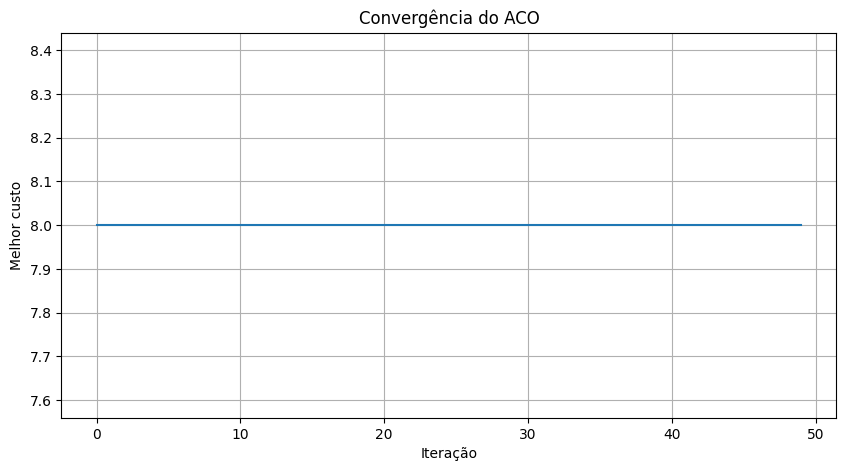

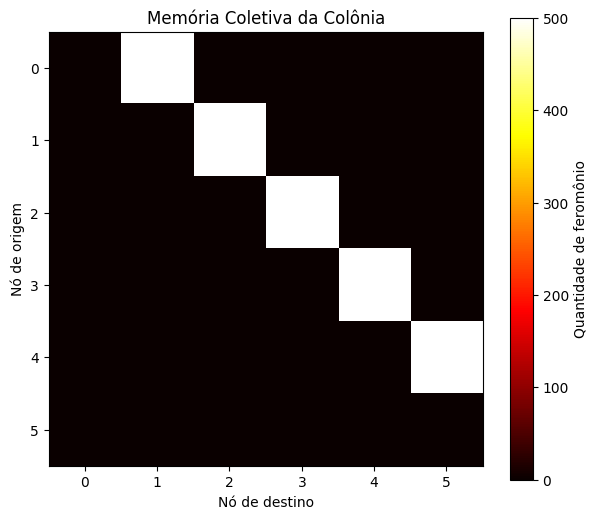

'Observe quais conexões apresentam maior concentração de feromônio. Para entrega: Execute o programa e observe:\n\n- A melhor rota encontrada.\n- O custo da melhor rota.\n- A curva de convergência.\n- A matriz final de feromônio.\n\nDepois responda às questões abaixo:\n\n1. Por que o ACO utiliza várias formigas em vez de apenas uma formiga procurando a melhor rota? Explique qual é a importância de explorar diferentes caminhos.\n\n2. Por que uma rota de menor custo recebe mais feromônio? Explique como essa regra influencia o comportamento das próximas formigas.\n\n3. O que poderia acontecer se não existisse evaporação do feromônio? Explique por que manter para sempre as primeiras informações encontradas poderia prejudicar a busca por soluções melhores.\n'

In [19]:
'''LABORATÓRIO — ACO: OTIMIZAÇÃO POR COLÔNIA DE FORMIGAS

Objetivo: Implementar uma versão simples do **Ant Colony Optimization (ACO)** para encontrar uma boa rota em uma rede de nós.

O algoritmo utiliza três ideias principais:

1. As formigas exploram diferentes caminhos.
2. Caminhos melhores recebem mais feromônio.
3. O feromônio influencia as próximas escolhas.'''


# 1. Importação das bibliotecas
import numpy as np
import random
import matplotlib.pyplot as plt

# 2. Representação da rede - Cada posição da matriz representa o custo para ir de um nó para outro.
#`np.inf` significa que **não existe uma conexão direta** entre os nós.

# ============================================================
# PARÂMETROS DO EXPERIMENTO
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5


## 3. Parâmetros do ACO
NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

# `ALPHA` controla a influência do feromônio.
# `BETA` controla a influência do custo do caminho.
# Quanto maior `BETA`, maior a preferência por caminhos de menor custo.

## 4. Criando a matriz de feromônio - Inicialmente, todos os caminhos existentes possuem a mesma quantidade de feromônio.

feromonio = np.ones_like(CUSTOS, dtype=float)

# Onde não existe conexão, não existe feromônio.
feromonio[CUSTOS == np.inf] = 0

print("Matriz inicial de feromônio:")
print(feromonio)

## 5. Encontrando os vizinhos de um nó - A formiga só pode caminhar para nós que possuem uma conexão direta.

def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(len(CUSTOS)):

        # Ignoramos o próprio nó e conexões inexistentes.
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos

#Teste:

print("Vizinhos do nó 0:", obter_vizinhos(0))
print("Vizinhos do nó 2:", obter_vizinhos(2))


## 6. Escolhendo o próximo nó - A formiga considera:
# * a quantidade de feromônio;
# * o custo do caminho.
# Um caminho com **mais feromônio** e **menor custo** tende a ser mais atrativo.

def escolher_proximo(no_atual, visitados):

    vizinhos = obter_vizinhos(no_atual)

# A formiga não pode voltar para um nó que já visitou.
    candidatos = [
        no for no in vizinhos
        if no not in visitados
    ]

    if not candidatos:
        return None

    atratividades = []

    for proximo in candidatos:

        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]

# Quanto maior o feromônio e menor o custo,
# maior será a atratividade do caminho.

        atratividade = (
            fer ** ALPHA
            * (1 / custo) ** BETA
        )

        atratividades.append(atratividade)

# Transformamos as atratividades em probabilidades.
    soma = sum(atratividades)

    probabilidades = [
        valor / soma
        for valor in atratividades
    ]

# A escolha é probabilística.
# Portanto, a formiga pode explorar diferentes caminhos.
    return random.choices(
        candidatos,
        weights=probabilidades,
        k=1
    )[0]


## 7. Construindo uma rota - Agora uma formiga começa no nó de origem e escolhe novos nós até chegar ao destino.

def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        proximo = escolher_proximo(
            atual,
            rota
        )

        if proximo is None:
            return None

        rota.append(proximo)
        atual = proximo

    return rota

# Teste algumas formigas:

print("\nRotas encontradas:")

for i in range(5):

    rota = construir_rota()

    print(f"Formiga {i + 1}: {rota}")

## 8. Calculando o custo da rota - O custo total é a soma dos custos de todos os enlaces utilizados.

def calcular_custo(rota):

    total = 0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        total += CUSTOS[origem][destino]

    return total

# Teste:

rota = construir_rota()

if rota is not None:

    custo = calcular_custo(rota)

    print("\nRota:", rota)
    print("Custo:", custo)


## 9. Depósito de feromônio - Depois que uma formiga termina sua rota, ela deixa feromônio no caminho percorrido. Rotas melhores recebem mais feromônio.

def depositar_feromonio(rota, custo):

# Quanto menor o custo, maior o depósito.
    deposito = Q / custo

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito


## 10. Evaporação do feromônio - O feromônio não permanece para sempre. A evaporação permite que novas experiências também tenham influência.

def evaporar_feromonio():

    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)

# Mantém zero onde não existe conexão.
    feromonio[CUSTOS == np.inf] = 0


## 11. Executando o ACO - Agora vamos juntar todas as etapas.

melhor_rota = None
melhor_custo = float("inf")

historico = []

for iteracao in range(NUM_ITERACOES):

    rotas = []

# Cada formiga constrói uma rota.
    for _ in range(NUM_FORMIGAS):

        rota = construir_rota()

        if rota is not None:

            custo = calcular_custo(rota)

            rotas.append((rota, custo))

            # Guarda a melhor solução encontrada até agora.
            if custo < melhor_custo:

                melhor_custo = custo
                melhor_rota = rota.copy()

# Primeiro diminuímos o feromônio existente.
    evaporar_feromonio()

# Depois reforçamos os caminhos utilizados pelas formigas.
    for rota, custo in rotas:

        depositar_feromonio(
            rota,
            custo
        )

# Guarda o melhor custo para visualizar a evolução.
    historico.append(melhor_custo)


print("\n========== RESULTADO ==========")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)

print("\n========== RESULTADO DO EXPERIMENTO lab 2 ==========")
print("Número de formigas:", NUM_FORMIGAS)
print("Número de iterações:", NUM_ITERACOES)
print("ALPHA:", ALPHA)
print("BETA:", BETA)
print("Taxa de evaporação:", TAXA_EVAPORACAO)
print("Melhor rota:", melhor_rota)
print("Melhor custo:", melhor_custo)


## 12. Visualizando a convergência - O gráfico mostra como a melhor solução encontrada evolui ao longo das iterações.

plt.figure(figsize=(10, 5))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO")
plt.grid()
plt.show()

# Observe se o custo diminui rapidamente no início e depois tende a se estabilizar.


## 13. Visualizando a matriz de feromônio - A matriz mostra onde o feromônio ficou mais concentrado depois da execução.

plt.figure(figsize=(7, 6))
plt.imshow(
    feromonio,
    cmap="hot"
)

plt.colorbar(
    label="Quantidade de feromônio"
)

plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")

plt.title("Memória Coletiva da Colônia")
plt.show()
# fim do código

'''Observe quais conexões apresentam maior concentração de feromônio. Para entrega: Execute o programa e observe:

- A melhor rota encontrada.
- O custo da melhor rota.
- A curva de convergência.
- A matriz final de feromônio.

Depois responda às questões abaixo:

1. Por que o ACO utiliza várias formigas em vez de apenas uma formiga procurando a melhor rota? Explique qual é a importância de explorar diferentes caminhos.

2. Por que uma rota de menor custo recebe mais feromônio? Explique como essa regra influencia o comportamento das próximas formigas.

3. O que poderia acontecer se não existisse evaporação do feromônio? Explique por que manter para sempre as primeiras informações encontradas poderia prejudicar a busca por soluções melhores.
'''


Matriz inicial de feromônio:
[[1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]]
Vizinhos do nó 0: [1, 2]
Vizinhos do nó 2: [0, 1, 3, 4]

Rotas encontradas:
Formiga 1: [0, 1, 2, 4, 3, 5]
Formiga 2: [0, 1, 2, 4, 3, 5]
Formiga 3: [0, 2, 1, 3, 4, 5]
Formiga 4: [0, 2, 1, 3, 4, 5]
Formiga 5: [0, 1, 2, 4, 3, 5]

Rota: [0, 2, 1, 3, 4, 5]
Custo: 13.0

========== RESULTADO ==========
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO lab 2 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 0.1
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


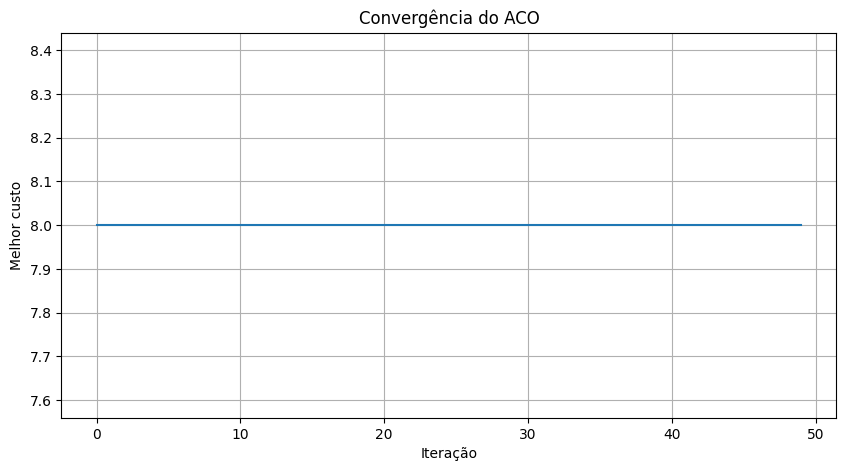

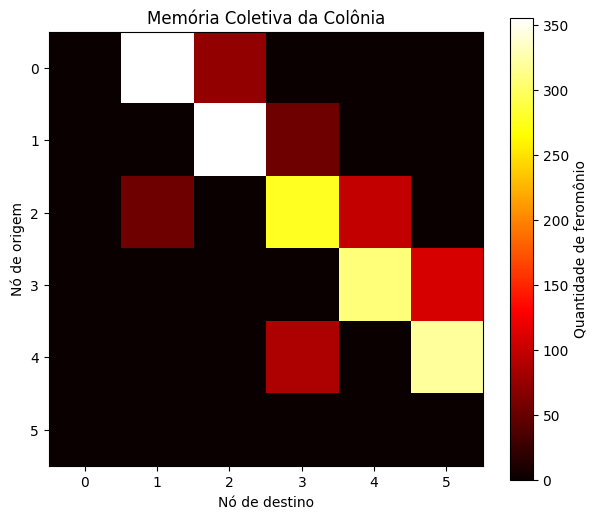

'Observe quais conexões apresentam maior concentração de feromônio. Para entrega: Execute o programa e observe:\n\n- A melhor rota encontrada.\n- O custo da melhor rota.\n- A curva de convergência.\n- A matriz final de feromônio.\n\nDepois responda às questões abaixo:\n\n1. Por que o ACO utiliza várias formigas em vez de apenas uma formiga procurando a melhor rota? Explique qual é a importância de explorar diferentes caminhos.\n\n2. Por que uma rota de menor custo recebe mais feromônio? Explique como essa regra influencia o comportamento das próximas formigas.\n\n3. O que poderia acontecer se não existisse evaporação do feromônio? Explique por que manter para sempre as primeiras informações encontradas poderia prejudicar a busca por soluções melhores.\n'

In [ ]:
'''LABORATÓRIO — ACO: OTIMIZAÇÃO POR COLÔNIA DE FORMIGAS

Objetivo: Implementar uma versão simples do **Ant Colony Optimization (ACO)** para encontrar uma boa rota em uma rede de nós.

O algoritmo utiliza três ideias principais:

1. As formigas exploram diferentes caminhos.
2. Caminhos melhores recebem mais feromônio.
3. O feromônio influencia as próximas escolhas.'''


# 1. Importação das bibliotecas
import numpy as np
import random
import matplotlib.pyplot as plt

# 2. Representação da rede - Cada posição da matriz representa o custo para ir de um nó para outro.
#`np.inf` significa que **não existe uma conexão direta** entre os nós.

# ============================================================
# PARÂMETROS DO EXPERIMENTO
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 0.1
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

# `ALPHA` controla a influência do feromônio.
# `BETA` controla a influência do custo do caminho.
# Quanto maior `BETA`, maior a preferência por caminhos de menor custo.

## 4. Criando a matriz de feromônio - Inicialmente, todos os caminhos existentes possuem a mesma quantidade de feromônio.

feromonio = np.ones_like(CUSTOS, dtype=float)

# Onde não existe conexão, não existe feromônio.
feromonio[CUSTOS == np.inf] = 0

print("Matriz inicial de feromônio:")
print(feromonio)

## 5. Encontrando os vizinhos de um nó - A formiga só pode caminhar para nós que possuem uma conexão direta.

def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(len(CUSTOS)):

        # Ignoramos o próprio nó e conexões inexistentes.
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos

#Teste:

print("Vizinhos do nó 0:", obter_vizinhos(0))
print("Vizinhos do nó 2:", obter_vizinhos(2))


## 6. Escolhendo o próximo nó - A formiga considera:
# * a quantidade de feromônio;
# * o custo do caminho.
# Um caminho com **mais feromônio** e **menor custo** tende a ser mais atrativo.

def escolher_proximo(no_atual, visitados):

    vizinhos = obter_vizinhos(no_atual)

# A formiga não pode voltar para um nó que já visitou.
    candidatos = [
        no for no in vizinhos
        if no not in visitados
    ]

    if not candidatos:
        return None

    atratividades = []

    for proximo in candidatos:

        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]

# Quanto maior o feromônio e menor o custo,
# maior será a atratividade do caminho.

        atratividade = (
            fer ** ALPHA
            * (1 / custo) ** BETA
        )

        atratividades.append(atratividade)

# Transformamos as atratividades em probabilidades.
    soma = sum(atratividades)

    probabilidades = [
        valor / soma
        for valor in atratividades
    ]

# A escolha é probabilística.
# Portanto, a formiga pode explorar diferentes caminhos.
    return random.choices(
        candidatos,
        weights=probabilidades,
        k=1
    )[0]


## 7. Construindo uma rota - Agora uma formiga começa no nó de origem e escolhe novos nós até chegar ao destino.

def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        proximo = escolher_proximo(
            atual,
            rota
        )

        if proximo is None:
            return None

        rota.append(proximo)
        atual = proximo

    return rota

# Teste algumas formigas:

print("\nRotas encontradas:")

for i in range(5):

    rota = construir_rota()

    print(f"Formiga {i + 1}: {rota}")

## 8. Calculando o custo da rota - O custo total é a soma dos custos de todos os enlaces utilizados.

def calcular_custo(rota):

    total = 0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        total += CUSTOS[origem][destino]

    return total

# Teste:

rota = construir_rota()

if rota is not None:

    custo = calcular_custo(rota)

    print("\nRota:", rota)
    print("Custo:", custo)


## 9. Depósito de feromônio - Depois que uma formiga termina sua rota, ela deixa feromônio no caminho percorrido. Rotas melhores recebem mais feromônio.

def depositar_feromonio(rota, custo):

# Quanto menor o custo, maior o depósito.
    deposito = Q / custo

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito


## 10. Evaporação do feromônio - O feromônio não permanece para sempre. A evaporação permite que novas experiências também tenham influência.

def evaporar_feromonio():

    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)

# Mantém zero onde não existe conexão.
    feromonio[CUSTOS == np.inf] = 0


## 11. Executando o ACO - Agora vamos juntar todas as etapas.

melhor_rota = None
melhor_custo = float("inf")

historico = []

for iteracao in range(NUM_ITERACOES):

    rotas = []

# Cada formiga constrói uma rota.
    for _ in range(NUM_FORMIGAS):

        rota = construir_rota()

        if rota is not None:

            custo = calcular_custo(rota)

            rotas.append((rota, custo))

            # Guarda a melhor solução encontrada até agora.
            if custo < melhor_custo:

                melhor_custo = custo
                melhor_rota = rota.copy()

# Primeiro diminuímos o feromônio existente.
    evaporar_feromonio()

# Depois reforçamos os caminhos utilizados pelas formigas.
    for rota, custo in rotas:

        depositar_feromonio(
            rota,
            custo
        )

# Guarda o melhor custo para visualizar a evolução.
    historico.append(melhor_custo)


print("\n========== RESULTADO ==========")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)

print("\n========== RESULTADO DO EXPERIMENTO lab 2 ==========")
print("Número de formigas:", NUM_FORMIGAS)
print("Número de iterações:", NUM_ITERACOES)
print("ALPHA:", ALPHA)
print("BETA:", BETA)
print("Taxa de evaporação:", TAXA_EVAPORACAO)
print("Melhor rota:", melhor_rota)
print("Melhor custo:", melhor_custo)


## 12. Visualizando a convergência - O gráfico mostra como a melhor solução encontrada evolui ao longo das iterações.

plt.figure(figsize=(10, 5))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO")
plt.grid()
plt.show()

# Observe se o custo diminui rapidamente no início e depois tende a se estabilizar.


## 13. Visualizando a matriz de feromônio - A matriz mostra onde o feromônio ficou mais concentrado depois da execução.

plt.figure(figsize=(7, 6))
plt.imshow(
    feromonio,
    cmap="hot"
)

plt.colorbar(
    label="Quantidade de feromônio"
)

plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")

plt.title("Memória Coletiva da Colônia")
plt.show()
# fim do código

'''Observe quais conexões apresentam maior concentração de feromônio. Para entrega: Execute o programa e observe:

- A melhor rota encontrada.
- O custo da melhor rota.
- A curva de convergência.
- A matriz final de feromônio.

Depois responda às questões abaixo:

1. Por que o ACO utiliza várias formigas em vez de apenas uma formiga procurando a melhor rota? Explique qual é a importância de explorar diferentes caminhos.

2. Por que uma rota de menor custo recebe mais feromônio? Explique como essa regra influencia o comportamento das próximas formigas.

3. O que poderia acontecer se não existisse evaporação do feromônio? Explique por que manter para sempre as primeiras informações encontradas poderia prejudicar a busca por soluções melhores.
'''


Matriz inicial de feromônio:
[[1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]]
Vizinhos do nó 0: [1, 2]
Vizinhos do nó 2: [0, 1, 3, 4]

Rotas encontradas:
Formiga 1: [0, 1, 2, 3, 4, 5]
Formiga 2: [0, 1, 2, 3, 4, 5]
Formiga 3: [0, 1, 2, 3, 4, 5]
Formiga 4: [0, 1, 3, 2, 4, 5]
Formiga 5: [0, 1, 2, 3, 4, 5]

Rota: [0, 1, 2, 3, 4, 5]
Custo: 8.0

========== RESULTADO ==========
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO lab 2 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 5.0
BETA: 2.0
Taxa de evaporação: 0.9
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


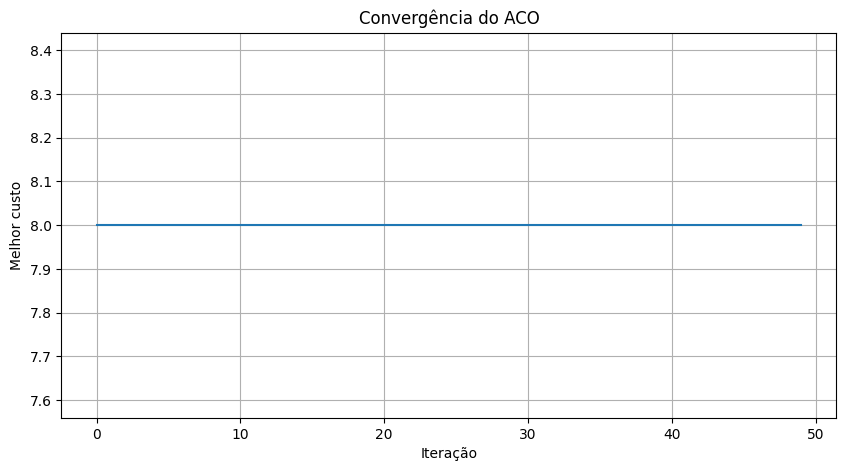

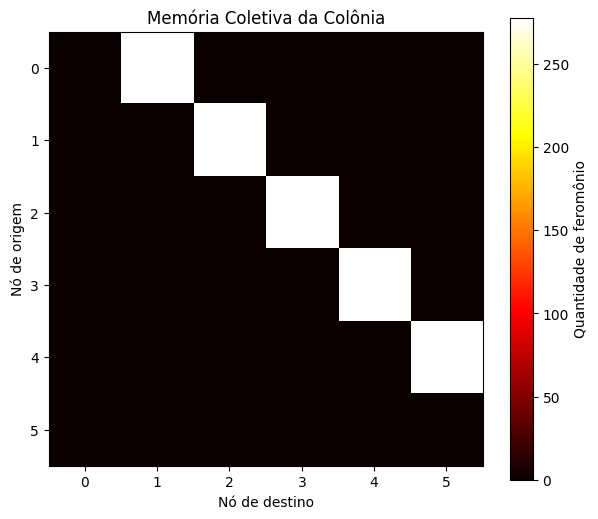

'Observe quais conexões apresentam maior concentração de feromônio. Para entrega: Execute o programa e observe:\n\n- A melhor rota encontrada.\n- O custo da melhor rota.\n- A curva de convergência.\n- A matriz final de feromônio.\n\nDepois responda às questões abaixo:\n\n1. Por que o ACO utiliza várias formigas em vez de apenas uma formiga procurando a melhor rota? Explique qual é a importância de explorar diferentes caminhos.\n\n2. Por que uma rota de menor custo recebe mais feromônio? Explique como essa regra influencia o comportamento das próximas formigas.\n\n3. O que poderia acontecer se não existisse evaporação do feromônio? Explique por que manter para sempre as primeiras informações encontradas poderia prejudicar a busca por soluções melhores.\n'

In [ ]:
'''LABORATÓRIO — ACO: OTIMIZAÇÃO POR COLÔNIA DE FORMIGAS

Objetivo: Implementar uma versão simples do **Ant Colony Optimization (ACO)** para encontrar uma boa rota em uma rede de nós.

O algoritmo utiliza três ideias principais:

1. As formigas exploram diferentes caminhos.
2. Caminhos melhores recebem mais feromônio.
3. O feromônio influencia as próximas escolhas.'''


# 1. Importação das bibliotecas
import numpy as np
import random
import matplotlib.pyplot as plt

# 2. Representação da rede - Cada posição da matriz representa o custo para ir de um nó para outro.
#`np.inf` significa que **não existe uma conexão direta** entre os nós.

# ============================================================
# PARÂMETROS DO EXPERIMENTO
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 5.0
BETA = 2.0

TAXA_EVAPORACAO = 0.9
Q = 100

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

# `ALPHA` controla a influência do feromônio.
# `BETA` controla a influência do custo do caminho.
# Quanto maior `BETA`, maior a preferência por caminhos de menor custo.

## 4. Criando a matriz de feromônio - Inicialmente, todos os caminhos existentes possuem a mesma quantidade de feromônio.

feromonio = np.ones_like(CUSTOS, dtype=float)

# Onde não existe conexão, não existe feromônio.
feromonio[CUSTOS == np.inf] = 0

print("Matriz inicial de feromônio:")
print(feromonio)

## 5. Encontrando os vizinhos de um nó - A formiga só pode caminhar para nós que possuem uma conexão direta.

def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(len(CUSTOS)):

        # Ignoramos o próprio nó e conexões inexistentes.
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos

#Teste:

print("Vizinhos do nó 0:", obter_vizinhos(0))
print("Vizinhos do nó 2:", obter_vizinhos(2))


## 6. Escolhendo o próximo nó - A formiga considera:
# * a quantidade de feromônio;
# * o custo do caminho.
# Um caminho com **mais feromônio** e **menor custo** tende a ser mais atrativo.

def escolher_proximo(no_atual, visitados):

    vizinhos = obter_vizinhos(no_atual)

# A formiga não pode voltar para um nó que já visitou.
    candidatos = [
        no for no in vizinhos
        if no not in visitados
    ]

    if not candidatos:
        return None

    atratividades = []

    for proximo in candidatos:

        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]

# Quanto maior o feromônio e menor o custo,
# maior será a atratividade do caminho.

        atratividade = (
            fer ** ALPHA
            * (1 / custo) ** BETA
        )

        atratividades.append(atratividade)

# Transformamos as atratividades em probabilidades.
    soma = sum(atratividades)

    probabilidades = [
        valor / soma
        for valor in atratividades
    ]

# A escolha é probabilística.
# Portanto, a formiga pode explorar diferentes caminhos.
    return random.choices(
        candidatos,
        weights=probabilidades,
        k=1
    )[0]


## 7. Construindo uma rota - Agora uma formiga começa no nó de origem e escolhe novos nós até chegar ao destino.

def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        proximo = escolher_proximo(
            atual,
            rota
        )

        if proximo is None:
            return None

        rota.append(proximo)
        atual = proximo

    return rota

# Teste algumas formigas:

print("\nRotas encontradas:")

for i in range(5):

    rota = construir_rota()

    print(f"Formiga {i + 1}: {rota}")

## 8. Calculando o custo da rota - O custo total é a soma dos custos de todos os enlaces utilizados.

def calcular_custo(rota):

    total = 0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        total += CUSTOS[origem][destino]

    return total

# Teste:

rota = construir_rota()

if rota is not None:

    custo = calcular_custo(rota)

    print("\nRota:", rota)
    print("Custo:", custo)


## 9. Depósito de feromônio - Depois que uma formiga termina sua rota, ela deixa feromônio no caminho percorrido. Rotas melhores recebem mais feromônio.

def depositar_feromonio(rota, custo):

# Quanto menor o custo, maior o depósito.
    deposito = Q / custo

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito


## 10. Evaporação do feromônio - O feromônio não permanece para sempre. A evaporação permite que novas experiências também tenham influência.

def evaporar_feromonio():

    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)

# Mantém zero onde não existe conexão.
    feromonio[CUSTOS == np.inf] = 0


## 11. Executando o ACO - Agora vamos juntar todas as etapas.

melhor_rota = None
melhor_custo = float("inf")

historico = []

for iteracao in range(NUM_ITERACOES):

    rotas = []

# Cada formiga constrói uma rota.
    for _ in range(NUM_FORMIGAS):

        rota = construir_rota()

        if rota is not None:

            custo = calcular_custo(rota)

            rotas.append((rota, custo))

            # Guarda a melhor solução encontrada até agora.
            if custo < melhor_custo:

                melhor_custo = custo
                melhor_rota = rota.copy()

# Primeiro diminuímos o feromônio existente.
    evaporar_feromonio()

# Depois reforçamos os caminhos utilizados pelas formigas.
    for rota, custo in rotas:

        depositar_feromonio(
            rota,
            custo
        )

# Guarda o melhor custo para visualizar a evolução.
    historico.append(melhor_custo)


print("\n========== RESULTADO ==========")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)

print("\n========== RESULTADO DO EXPERIMENTO lab 2 ==========")
print("Número de formigas:", NUM_FORMIGAS)
print("Número de iterações:", NUM_ITERACOES)
print("ALPHA:", ALPHA)
print("BETA:", BETA)
print("Taxa de evaporação:", TAXA_EVAPORACAO)
print("Melhor rota:", melhor_rota)
print("Melhor custo:", melhor_custo)


## 12. Visualizando a convergência - O gráfico mostra como a melhor solução encontrada evolui ao longo das iterações.

plt.figure(figsize=(10, 5))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO")
plt.grid()
plt.show()

# Observe se o custo diminui rapidamente no início e depois tende a se estabilizar.


## 13. Visualizando a matriz de feromônio - A matriz mostra onde o feromônio ficou mais concentrado depois da execução.

plt.figure(figsize=(7, 6))
plt.imshow(
    feromonio,
    cmap="hot"
)

plt.colorbar(
    label="Quantidade de feromônio"
)

plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")

plt.title("Memória Coletiva da Colônia")
plt.show()
# fim do código

'''Observe quais conexões apresentam maior concentração de feromônio. Para entrega: Execute o programa e observe:

- A melhor rota encontrada.
- O custo da melhor rota.
- A curva de convergência.
- A matriz final de feromônio.

Depois responda às questões abaixo:

1. Por que o ACO utiliza várias formigas em vez de apenas uma formiga procurando a melhor rota? Explique qual é a importância de explorar diferentes caminhos.

2. Por que uma rota de menor custo recebe mais feromônio? Explique como essa regra influencia o comportamento das próximas formigas.

3. O que poderia acontecer se não existisse evaporação do feromônio? Explique por que manter para sempre as primeiras informações encontradas poderia prejudicar a busca por soluções melhores.
'''
